# Compare makeKinematicPlots outputs

Overlays 1D and 2D histograms from multiple `makeKinematicPlots` output ROOT files.

**Naming convention** (from the C++ code):
- `h{Var}_{pip|pim}_{j}_{k}` where `j` = Q² bin (0 = inclusive), `k` = xB bin (0 = inclusive)
- 2D: `hQ2_{Xb|omega|Z|W}_{pip|pim}_{j}_{k}`

In [375]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as mcm
import os

In [ ]:
# ── Configuration ─────────────────────────────────────────────────────────────
#
# Each entry: (path, label)
FILES = [
    #('../histograms/analysis_note/kinematic_plots_dat_d_10.2_dep.root',  'Deuteron Data'),
    #('../histograms/analysis_note/kinematic_plots_gemc_10.2.root',   '10.2 Sim'),
    #('../histograms/analysis_note/kinematic_plots_gen_10.2.root',   '10.2 Gen'),

    #('../histograms/analysis_note/kinematic_plots_gemc_10.4.root',   '10.4 Sim'),
    #('../histograms/analysis_note/kinematic_plots_gemc_10.6.root',   '10.6 Sim'),

    #('../histograms/analysis_note/kinematic_plots_dat_p_10.2_dep.root',  'Proton Data'),
    #('../histograms/analysis_note/kinematic_plots_gen_10637.root',   '10637 Gen'),
    #('../histograms/analysis_note/kinematic_plots_gen_10820.root',   '10820 Gen'),
    #('../histograms/analysis_note/kinematic_plots_gemc_10637.root',   'gemc 10637'),
    #('../histograms/analysis_note/kinematic_plots_gemc_10637_det.root',   'gemc 10637 dert'),

    #('../histograms/analysis_note/kinematic_plots_gemc_10820.root',   'gemc 10820'),
    #('../histograms/analysis_note/kinematic_plots_gemc_10892.root',   '10892'),

    #    ('../histograms/analysis_note/kinematic_plots_gemc_d_10.2_dep.root',   'Deuterium Sim'),

]

# Kinematic bin to display — both 0 = fully inclusive
Q2_BIN = 0   # 0 = inclusive; 1..bins_Q2 for a specific Q² bin
XB_BIN = 0   # 0 = inclusive; 1..bins_xB for a specific xB bin

# Which charges to show: 'pip', 'pim', or 'both'
CHARGES = 'pip'

# Normalise each histogram to unit area before comparing
NORMALIZE = False

# Output directory — None = display inline
OUT_DIR = None

In [377]:
# ── Style ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.edgecolor':    '#444444',
    'axes.linewidth':    0.8,
    'axes.grid':         True,
    'grid.color':        '#dddddd',
    'grid.linewidth':    0.5,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'xtick.major.size':  3,
    'ytick.major.size':  3,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'legend.framealpha': 0.9,
    'legend.edgecolor':  '#cccccc',
    'font.family':       'sans-serif',
})

_cmap       = mcm.get_cmap('tab10')
FILE_COLORS = [_cmap(i / 10) for i in range(10)]
LINESTYLES  = ['-', '--', ':', '-.']

CHARGE_LINESTYLE = {'pip': '-', 'pim': '--'}
CHARGE_LABEL     = {'pip': r'$\pi^+$', 'pim': r'$\pi^-$'}

/var/folders/4d/9x90517x6q3cc4_sz1jrqlj00000gn/T/ipykernel_12230/3791872820.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  _cmap       = mcm.get_cmap('tab10')


In [378]:
# ── Load all files ─────────────────────────────────────────────────────────────
datasets = []
for path, label in FILES:
    try:
        f = uproot.open(path)
        datasets.append({'file': f, 'label': label, 'path': path})
        print(f'OK    {label:20s}  {path}')
    except Exception as exc:
        print(f'SKIP  {label}: {exc}')

assert datasets, 'No files loaded — check FILES.'

# Resolved charge list
charge_list = ['pip', 'pim'] if CHARGES == 'both' else [CHARGES]

BIN_TAG = f'{Q2_BIN}_{XB_BIN}'
print(f'\nBin: Q2_BIN={Q2_BIN}, XB_BIN={XB_BIN}  (0 = inclusive)')
print(f'Charges: {charge_list}')

OK    10.2 Sim              ../histograms/analysis_note/kinematic_plots_gemc_10.2.root
OK    10.2 Gen              ../histograms/analysis_note/kinematic_plots_gen_10.2.root

Bin: Q2_BIN=0, XB_BIN=0  (0 = inclusive)
Charges: ['pip']


In [379]:
# ── Helpers ────────────────────────────────────────────────────────────────────
def _load_1d(f, hname):
    """Return (centers, values, errors) for a TH1, or None."""
    key = hname + ';1' if (hname + ';1') in f else hname
    if key not in f:
        return None
    h = f[key]
    edges   = h.axis().edges()
    centers = 0.5 * (edges[:-1] + edges[1:])
    v = np.array(h.values(),   dtype=float)
    e = np.sqrt(np.array(h.variances(), dtype=float))
    return centers, v, e


def _load_2d(f, hname):
    """Return (x_centers, y_centers, values) for a TH2, or None."""
    key = hname + ';1' if (hname + ';1') in f else hname
    if key not in f:
        return None
    h  = f[key]
    xe = h.axes[0].edges()
    ye = h.axes[1].edges()
    xc = 0.5 * (xe[:-1] + xe[1:])
    yc = 0.5 * (ye[:-1] + ye[1:])
    return xc, yc, np.array(h.values(), dtype=float)


def _norm(v, e):
    """Normalise to unit area (sum of bin contents × width ≈ 1)."""
    s = v.sum()
    if s == 0:
        return v, e
    return v / s, e / s


def _draw_1d(ax, hist_base, xlabel, title=None, ratio_ax=None):
    """
    Overlay hist_base_{charge}_{BIN_TAG} from all files onto ax.
    If ratio_ax is given, draw data[0]/data[i] ratio below.
    """
    ref_by_charge = {}   # store first-file result for ratio

    has_data = False
    for fi, d in enumerate(datasets):
        color = FILE_COLORS[fi % len(FILE_COLORS)]
        for charge in charge_list:
            hname = f'{hist_base}_{charge}_{BIN_TAG}'
            result = _load_1d(d['file'], hname)
            if result is None:
                continue
            centers, v, e = result
            if NORMALIZE:
                v, e = _norm(v, e)
            ls  = CHARGE_LINESTYLE[charge]
            lbl = d['label']
            if CHARGES == 'both':
                lbl += f' {CHARGE_LABEL[charge]}'
            ax.step(centers, v, color=color, lw=1.4, linestyle=ls,
                    where='mid', label=lbl)
            ax.fill_between(centers, v - e, v + e,
                            color=color, alpha=0.10, step='mid')
            has_data = True

            if ratio_ax is not None:
                key = charge
                if fi == 0:
                    ref_by_charge[key] = (centers, v, e)
                else:
                    ref_c, ref_v, ref_e = ref_by_charge.get(key, (None, None, None))
                    if ref_v is not None and len(ref_v) == len(v):
                        with np.errstate(invalid='ignore', divide='ignore'):
                            rat   = np.where(ref_v > 0, v / ref_v, np.nan)
                            rat_e = np.where(ref_v > 0,
                                             rat * np.sqrt((e/np.where(v>0,v,1))**2 +
                                                           (ref_e/np.where(ref_v>0,ref_v,1))**2),
                                             np.nan)
                        ratio_ax.step(centers, rat, color=color, lw=1.2,
                                      linestyle=ls, where='mid')
                        ratio_ax.fill_between(centers,
                                              np.where(np.isfinite(rat), rat-rat_e, np.nan),
                                              np.where(np.isfinite(rat), rat+rat_e, np.nan),
                                              color=color, alpha=0.10, step='mid')

    ax.set_ylabel('Counts [a.u.]' if not NORMALIZE else 'Normalised', fontsize=10)
    if title:
        ax.set_title(title, fontsize=10)
    if ratio_ax is not None:
        ratio_ax.axhline(1, color='#666666', lw=0.8, ls='--')
        ratio_ax.set_ylabel(f'{datasets[1]["label"] if len(datasets)>1 else "ratio"} / {datasets[0]["label"]}',
                            fontsize=8)
        ratio_ax.set_ylim(0.5, 1.5)
        ratio_ax.set_xlabel(xlabel, fontsize=10)
    else:
        ax.set_xlabel(xlabel, fontsize=10)
    return has_data

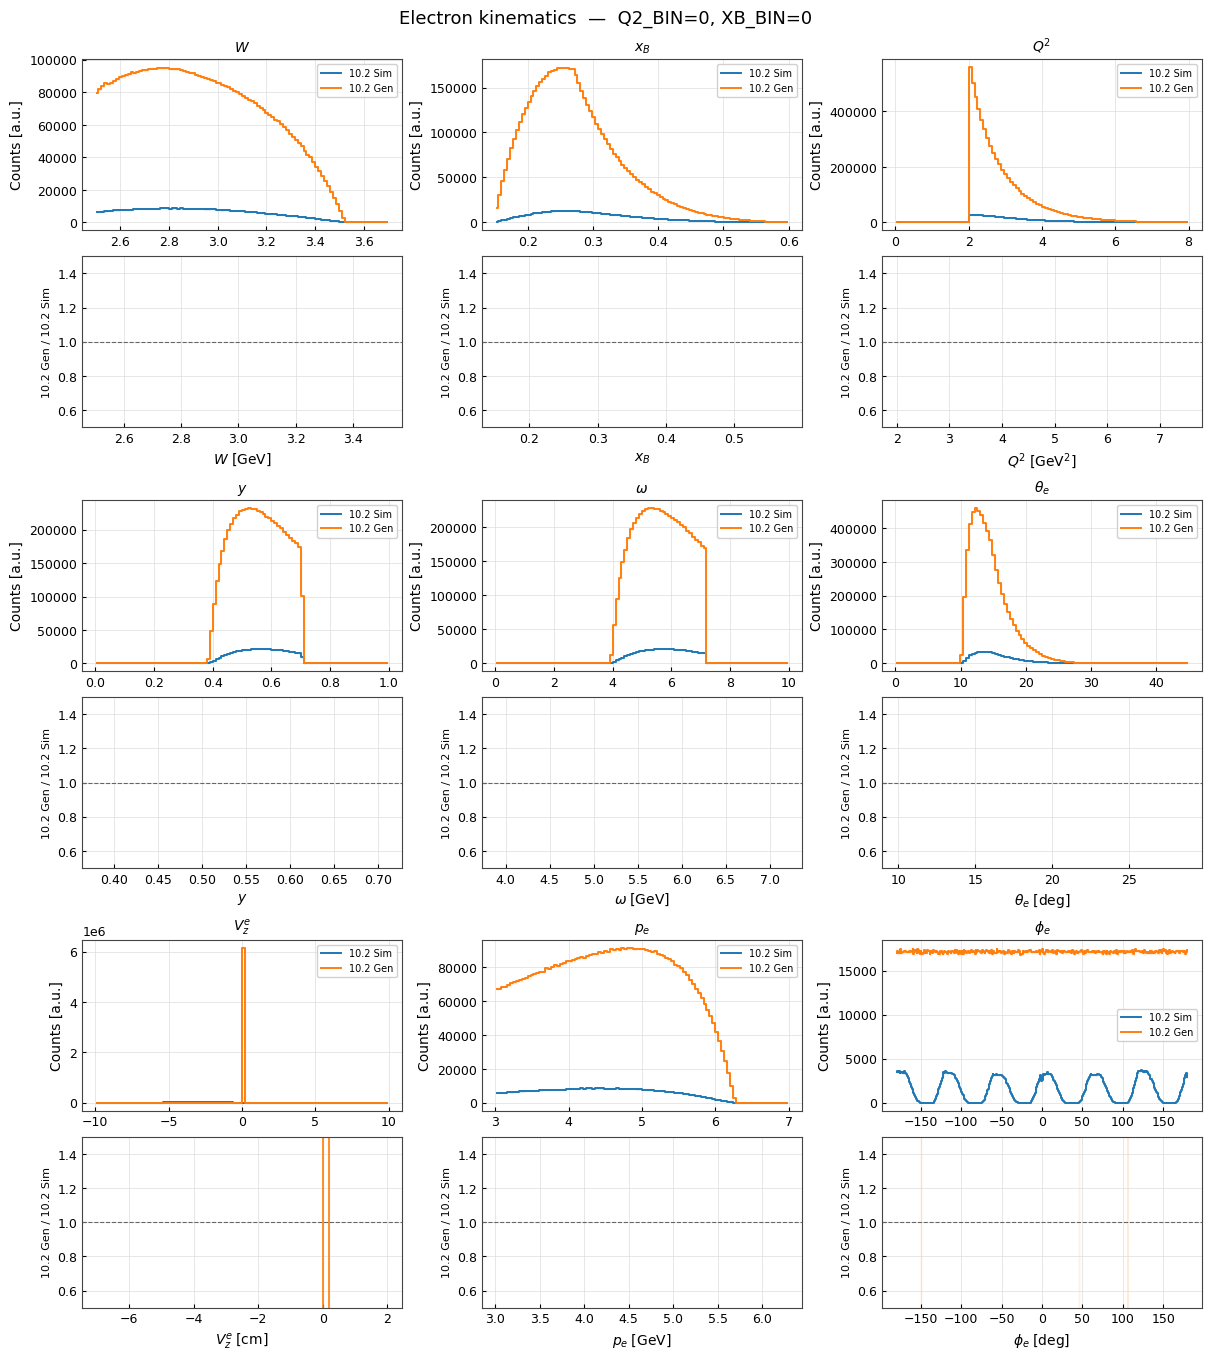

In [380]:
# ── 1D plots: electron kinematics ─────────────────────────────────────────────
if OUT_DIR:
    os.makedirs(OUT_DIR, exist_ok=True)

electron_vars = [
    ('hW',       r'$W$ [GeV]',                          '$W$'),
    ('hXb',      r'$x_B$',                              r'$x_B$'),
    ('hQ2',      r'$Q^2\;[\mathrm{GeV}^2]$',            r'$Q^2$'),
    ('hY',       r'$y$',                                r'$y$'),
    ('hOmega',   r'$\omega\;[\mathrm{GeV}]$',           r'$\omega$'),
    ('hTheta_e', r'$\theta_e\;[\mathrm{deg}]$',         r'$\theta_e$'),
    ('hVz_e',    r'$V_z^e\;[\mathrm{cm}]$',             r'$V_z^e$'),
    ('hP_e',     r'$p_e\;[\mathrm{GeV}]$',              r'$p_e$'),
    ('hPhi_e',   r'$\phi_e\;[\mathrm{deg}]$',           r'$\phi_e$'),
]

show_ratio = len(datasets) == 2
ncols = 3
nrows = -(-len(electron_vars) // ncols)
hr = [3, 1] if show_ratio else [1]
fig, axs_all = plt.subplots(
    nrows * (2 if show_ratio else 1), ncols,
    figsize=(ncols * 4.0, nrows * (4.5 if show_ratio else 3.5)),
    constrained_layout=True
)
fig.suptitle(f'Electron kinematics  —  Q2_BIN={Q2_BIN}, XB_BIN={XB_BIN}', fontsize=13)
axs_flat = np.array(axs_all).ravel()

row_stride = ncols * (2 if show_ratio else 1)
for vi, (hbase, xlabel, title) in enumerate(electron_vars):
    if show_ratio:
        row  = vi // ncols
        col  = vi %  ncols
        main_i  = row * 2 * ncols + col
        ratio_i = main_i + ncols
        ax_main  = axs_flat[main_i]
        ax_ratio = axs_flat[ratio_i]
    else:
        ax_main  = axs_flat[vi]
        ax_ratio = None

    _draw_1d(ax_main, hbase, xlabel, title, ax_ratio)
    ax_main.legend(fontsize=7, loc='best')

# Hide unused panels
for vi in range(len(electron_vars), nrows * ncols):
    if show_ratio:
        row = vi // ncols
        col = vi %  ncols
        axs_flat[row * 2 * ncols + col].set_visible(False)
        axs_flat[row * 2 * ncols + col + ncols].set_visible(False)
    else:
        axs_flat[vi].set_visible(False)

if OUT_DIR:
    fname = f'{OUT_DIR}/electron_kin_{BIN_TAG}.png'
    fig.savefig(fname, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f'Saved {fname}')
else:
    plt.show()

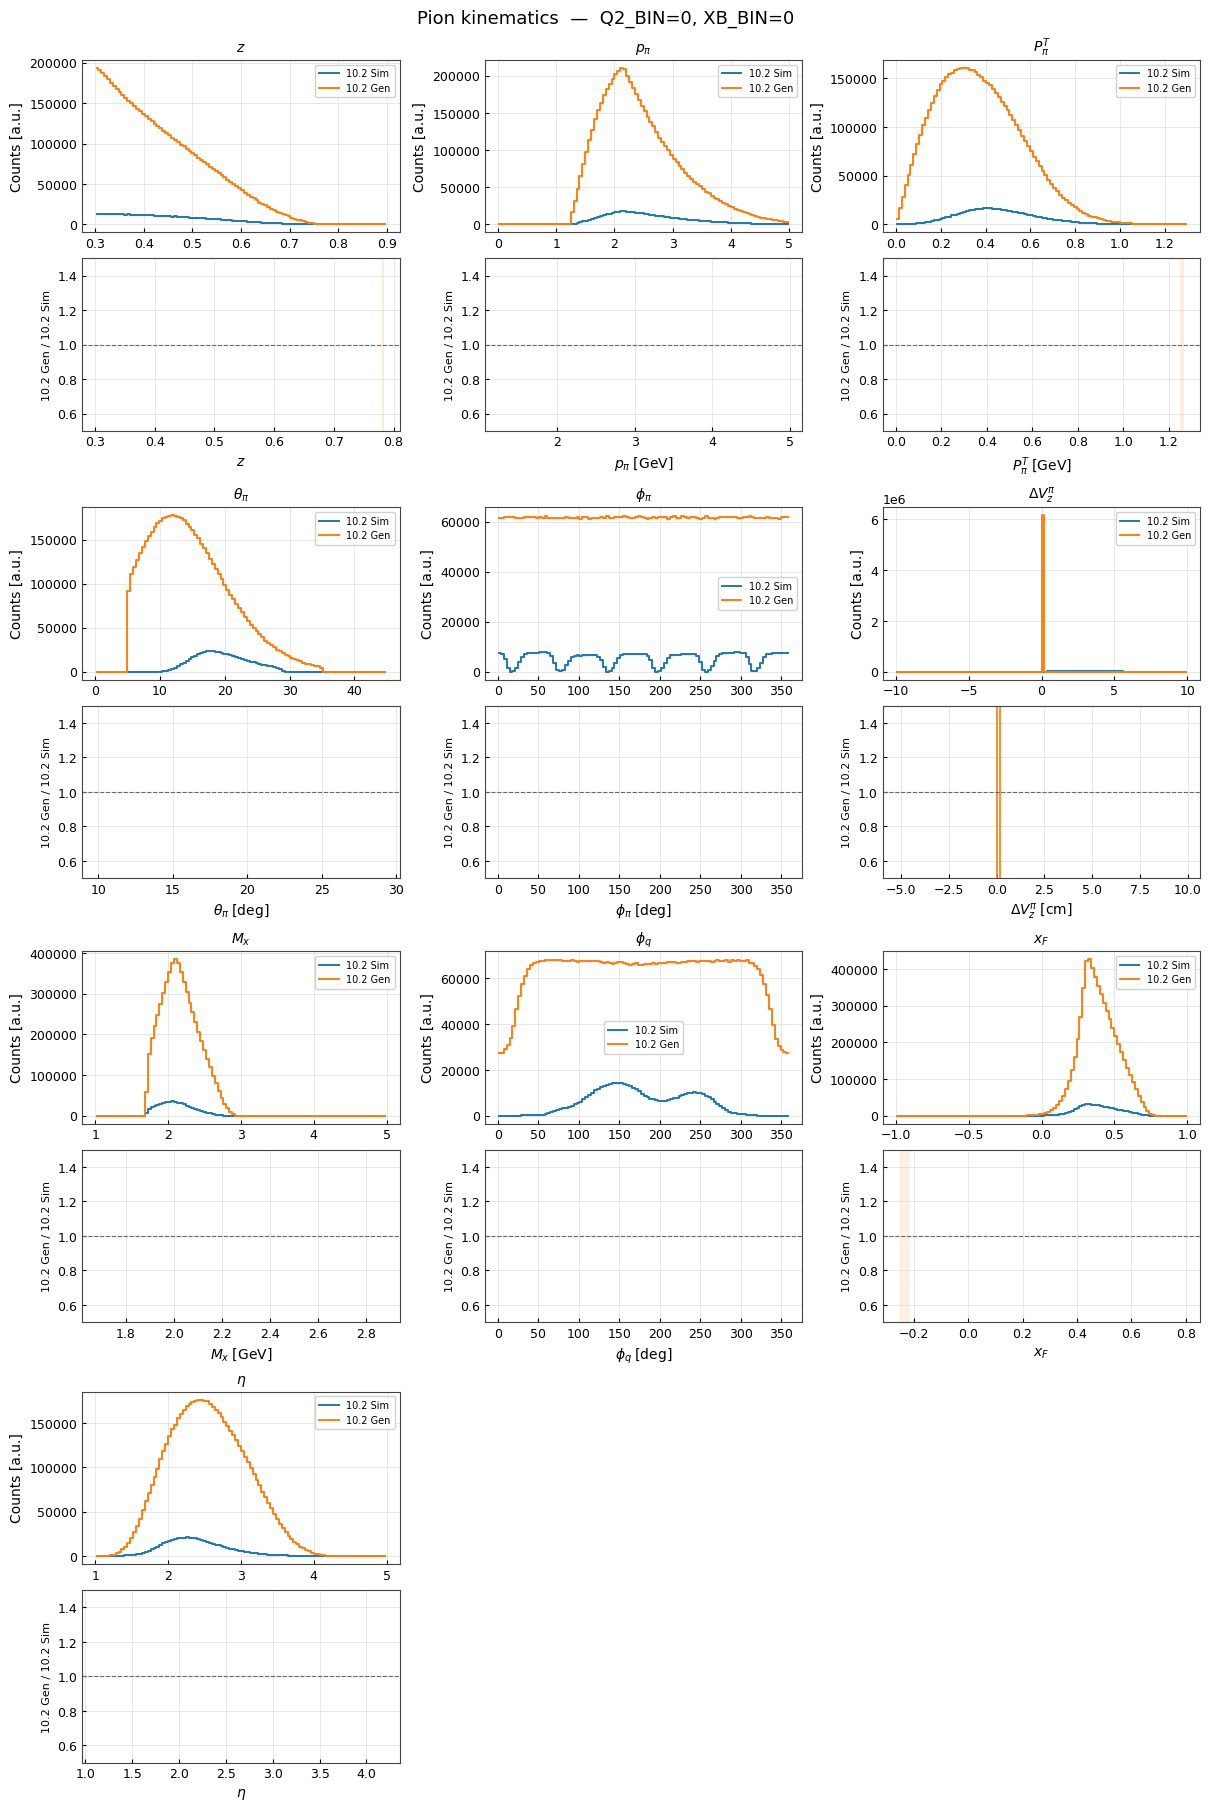

In [381]:
# ── 1D plots: pion kinematics ─────────────────────────────────────────────────
pion_vars = [
    ('hZ',        r'$z$',                                     r'$z$'),
    ('hP_pi',     r'$p_\pi\;[\mathrm{GeV}]$',                r'$p_\pi$'),
    ('hPt_pi',    r'$P_\pi^T\;[\mathrm{GeV}]$',              r'$P_\pi^T$'),
    ('hTheta_pi', r'$\theta_\pi\;[\mathrm{deg}]$',           r'$\theta_\pi$'),
    ('hPhi_pi',   r'$\phi_\pi\;[\mathrm{deg}]$',             r'$\phi_\pi$'),
    ('hVz_pi',    r'$\Delta V_z^\pi\;[\mathrm{cm}]$',        r'$\Delta V_z^\pi$'),
    ('hMx',       r'$M_x\;[\mathrm{GeV}]$',                  r'$M_x$'),
    ('hPhi_q',    r'$\phi_q\;[\mathrm{deg}]$',               r'$\phi_q$'),
    ('hXf',       r'$x_F$',                                   r'$x_F$'),
    ('hEta',      r'$\eta$',                                  r'$\eta$'),
]

nrows = -(-len(pion_vars) // ncols)
fig, axs_all = plt.subplots(
    nrows * (2 if show_ratio else 1), ncols,
    figsize=(ncols * 4.0, nrows * (4.5 if show_ratio else 3.5)),
    constrained_layout=True
)
fig.suptitle(f'Pion kinematics  —  Q2_BIN={Q2_BIN}, XB_BIN={XB_BIN}', fontsize=13)
axs_flat = np.array(axs_all).ravel()

for vi, (hbase, xlabel, title) in enumerate(pion_vars):
    if show_ratio:
        row  = vi // ncols
        col  = vi %  ncols
        ax_main  = axs_flat[row * 2 * ncols + col]
        ax_ratio = axs_flat[row * 2 * ncols + col + ncols]
    else:
        ax_main  = axs_flat[vi]
        ax_ratio = None

    _draw_1d(ax_main, hbase, xlabel, title, ax_ratio)
    ax_main.legend(fontsize=7, loc='best')

for vi in range(len(pion_vars), nrows * ncols):
    if show_ratio:
        row = vi // ncols
        col = vi %  ncols
        axs_flat[row * 2 * ncols + col].set_visible(False)
        axs_flat[row * 2 * ncols + col + ncols].set_visible(False)
    else:
        axs_flat[vi].set_visible(False)

if OUT_DIR:
    fname = f'{OUT_DIR}/pion_kin_{BIN_TAG}.png'
    fig.savefig(fname, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f'Saved {fname}')
else:
    plt.show()

/var/folders/4d/9x90517x6q3cc4_sz1jrqlj00000gn/T/ipykernel_12230/2156559868.py:48: RuntimeWarning: divide by zero encountered in log10
  disp = np.where(vals > 0, np.log10(vals), np.nan)


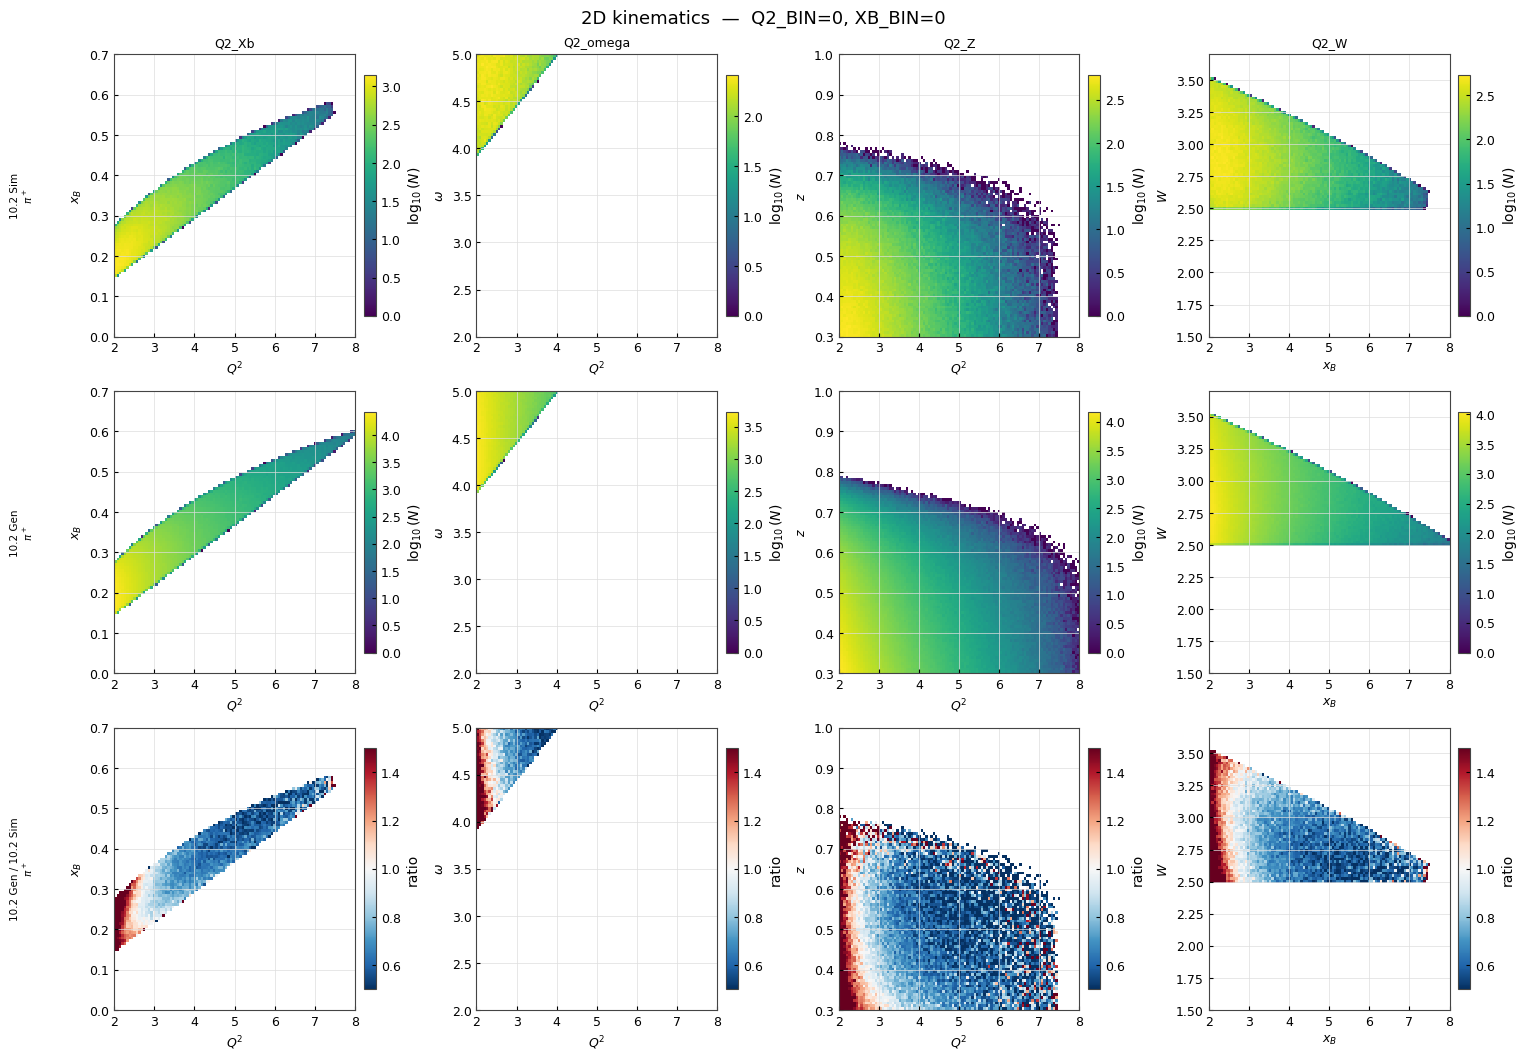

In [382]:
# ── 2D plots: Q2 correlations (+ data/sim ratio rows) ────────────────────────
# Rows: one per file × charge; if exactly 2 files an extra ratio row is appended
# per charge showing file[1] / file[0].
twod_vars = [
    ('hQ2_Xb',    r'$Q^2$', r'$x_B$'),
    ('hQ2_omega', r'$Q^2$', r'$\omega$'),
    ('hQ2_Z',     r'$Q^2$', r'$z$'),
    ('hQ2_W',     r'$x_B$', r'$W$'),
]

n2d_cols  = len(twod_vars)
show_2d_ratio = len(datasets) == 2

# Build row list: (label, charge, is_ratio)
rows_2d = []
for charge in charge_list:
    for d in datasets:
        rows_2d.append((d['label'], charge, False))
    if show_2d_ratio:
        rows_2d.append((f"{datasets[1]['label']} / {datasets[0]['label']}", charge, True))

fig, axs = plt.subplots(
    len(rows_2d), n2d_cols,
    figsize=(n2d_cols * 3.8, len(rows_2d) * 3.5),
    constrained_layout=True
)
if len(rows_2d) == 1:
    axs = axs[np.newaxis, :]
fig.suptitle(f'2D kinematics  —  Q2_BIN={Q2_BIN}, XB_BIN={XB_BIN}', fontsize=13)

# Cache loaded arrays for ratio computation
cache_2d = {}   # (label, charge, hbase) → vals

for ri, (label, charge, is_ratio) in enumerate(rows_2d):
    for ci, (hbase, xlabel, ylabel) in enumerate(twod_vars):
        ax = axs[ri, ci]

        if not is_ratio:
            d = next(d for d in datasets if d['label'] == label)
            result = _load_2d(d['file'], f'{hbase}_{charge}_{BIN_TAG}')
            if result is None:
                ax.text(0.5, 0.5, 'missing', transform=ax.transAxes,
                        ha='center', va='center', fontsize=9, color='grey')
                continue
            xc, yc, vals = result
            cache_2d[(label, charge, hbase)] = (xc, yc, vals)
            with np.errstate(invalid='ignore'):
                disp = np.where(vals > 0, np.log10(vals), np.nan)
            im = ax.pcolormesh(xc, yc, disp.T, cmap='viridis', shading='auto')
            plt.colorbar(im, ax=ax, fraction=0.05, pad=0.02, label=r'$\log_{10}(N)$')
        else:
            # ratio: file[1] / file[0], normalised so total counts match
            key0 = (datasets[0]['label'], charge, hbase)
            key1 = (datasets[1]['label'], charge, hbase)
            if key0 not in cache_2d or key1 not in cache_2d:
                ax.text(0.5, 0.5, 'missing', transform=ax.transAxes,
                        ha='center', va='center', fontsize=9, color='grey')
                continue
            xc, yc, v0 = cache_2d[key0]
            _,   _,  v1 = cache_2d[key1]
            # normalise each to unit area before taking ratio
            s0 = v0.sum(); s1 = v1.sum()
            n0 = v0 / s0 if s0 > 0 else v0
            n1 = v1 / s1 if s1 > 0 else v1
            with np.errstate(invalid='ignore', divide='ignore'):
                rat = np.where((n0 > 0) & (n1 > 0), n1 / n0, np.nan)
            im = ax.pcolormesh(xc, yc, rat.T, cmap='RdBu_r', shading='auto',
                               vmin=0.5, vmax=1.5)
            plt.colorbar(im, ax=ax, fraction=0.05, pad=0.02, label='ratio')

        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_ylabel(ylabel, fontsize=9)
        if ri == 0:
            ax.set_title(f'{hbase.replace("h","",1)}', fontsize=9)
        if ci == 0:
            row_label = label if not is_ratio else label
            ax.text(-0.38, 0.5, f'{row_label}\n{CHARGE_LABEL[charge]}',
                    transform=ax.transAxes, ha='center', va='center',
                    fontsize=7.5, rotation=90)

if OUT_DIR:
    fname = f'{OUT_DIR}/2d_kin_{BIN_TAG}.png'
    fig.savefig(fname, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f'Saved {fname}')
else:
    plt.show()

/var/folders/4d/9x90517x6q3cc4_sz1jrqlj00000gn/T/ipykernel_12230/2992580462.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  _q2_cmap  = mcm.get_cmap('plasma')


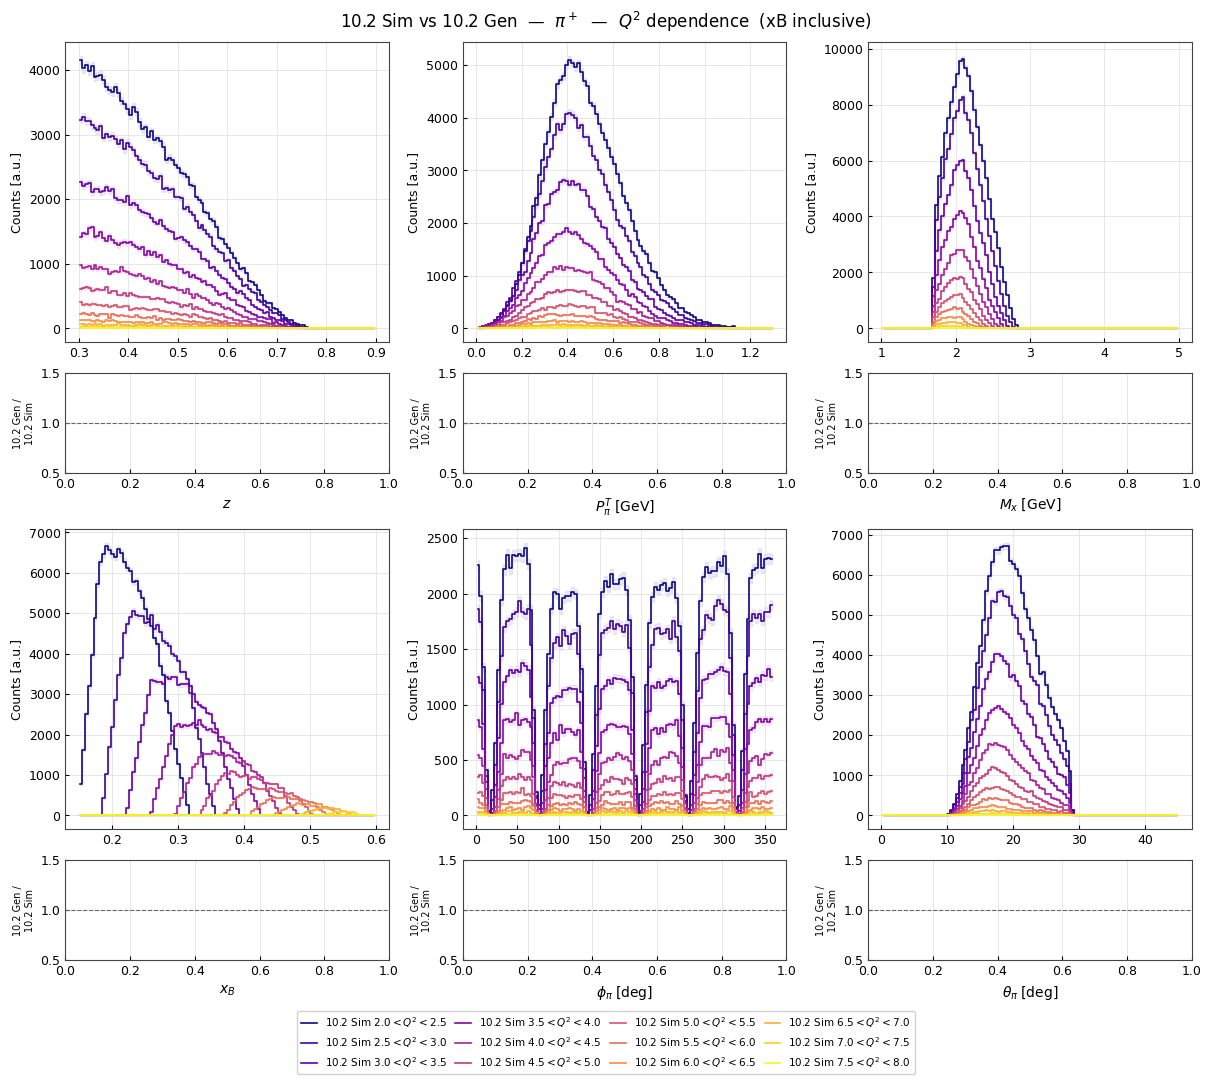

In [383]:
# ── Q² dependence: overlay Q² bins, fix XB_BIN=0 (+ data/sim ratio panels) ───
# When exactly 2 files are loaded, a ratio panel (file[1]/file[0]) appears below
# each main panel for every Q² bin.

BINS_Q2 = 12;  Q2_MIN, Q2_MAX = 2.0, 8.0

def q2_label(j):
    lo = Q2_MIN + (j - 1) * (Q2_MAX - Q2_MIN) / BINS_Q2
    hi = Q2_MIN +  j      * (Q2_MAX - Q2_MIN) / BINS_Q2
    return rf'${lo:.1f}<Q^2<{hi:.1f}$'

_q2_cmap  = mcm.get_cmap('plasma')
Q2_COLORS = [_q2_cmap(i / (BINS_Q2 - 1)) for i in range(BINS_Q2)]

Q2DEP_VARS = [
    ('hZ',        r'$z$'),
    ('hPt_pi',    r'$P_\pi^T\;[\mathrm{GeV}]$'),
    ('hMx',       r'$M_x\;[\mathrm{GeV}]$'),
    ('hXb',       r'$x_B$'),
    ('hPhi_pi',   r'$\phi_\pi\;[\mathrm{deg}]$'),
    ('hTheta_pi', r'$\theta_\pi\;[\mathrm{deg}]$'),
]

show_q2_ratio = len(datasets) == 2
ncols_q = 3
nrows_q = -(-len(Q2DEP_VARS) // ncols_q)
panel_rows = nrows_q * 2 if show_q2_ratio else nrows_q

for charge in charge_list:
    fig, axs = plt.subplots(
        panel_rows, ncols_q,
        figsize=(ncols_q * 4.0, panel_rows * (2.5 if show_q2_ratio else 3.5)),
        constrained_layout=True,
        gridspec_kw={'height_ratios': ([3, 1] * nrows_q if show_q2_ratio else None)}
    )
    title_files = f"{datasets[0]['label']}" + (f" vs {datasets[1]['label']}" if show_q2_ratio else "")
    fig.suptitle(
        rf"{title_files}  —  {CHARGE_LABEL[charge]}  —  $Q^2$ dependence  (xB inclusive)",
        fontsize=12
    )
    axs_flat = np.array(axs).ravel()

    for vi, (hbase, xlabel) in enumerate(Q2DEP_VARS):
        row = vi // ncols_q
        col = vi %  ncols_q
        if show_q2_ratio:
            ax_main  = axs_flat[row * 2 * ncols_q + col]
            ax_ratio = axs_flat[row * 2 * ncols_q + col + ncols_q]
        else:
            ax_main  = axs_flat[vi]
            ax_ratio = None

        # Collect normalised histograms per file for ratio
        ref_v = ref_c = None
        for fi, d in enumerate(datasets):
            color = FILE_COLORS[fi % len(FILE_COLORS)]
            for j in range(1, BINS_Q2 + 1):
                result = _load_1d(d['file'], f'{hbase}_{charge}_{j}_0')
                if result is None:
                    continue
                centers, v, e = result
                if NORMALIZE:
                    v, e = _norm(v, e)
                q_color = Q2_COLORS[(j - 1) % len(Q2_COLORS)]
                ls = LINESTYLES[fi % len(LINESTYLES)]
                lbl = (f"{d['label']} " if len(datasets) > 1 else "") + q2_label(j)
                ax_main.step(centers, v, color=q_color, lw=1.2, ls=ls,
                             where='mid', label=lbl if fi == 0 else '_nolegend_')
                ax_main.fill_between(centers, v - e, v + e,
                                     color=q_color, alpha=0.08, step='mid')

                if show_q2_ratio:
                    if fi == 0:
                        if ref_v is None:
                            ref_v = {}; ref_c = {}
                        ref_v[j] = v; ref_c[j] = centers
                    else:
                        if ref_v and j in ref_v and len(v) == len(ref_v[j]):
                            with np.errstate(invalid='ignore', divide='ignore'):
                                rat   = np.where(ref_v[j] > 0, v / ref_v[j], np.nan)
                                rat_e = np.where(ref_v[j] > 0,
                                                 rat * np.sqrt((e / np.where(v > 0, v, 1))**2 +
                                                               (0)),   # ref error small
                                                 np.nan)
                            ax_ratio.step(ref_c[j], rat, color=q_color, lw=1.0,
                                          where='mid', label=q2_label(j))
                            ax_ratio.fill_between(ref_c[j],
                                                  np.where(np.isfinite(rat), rat - rat_e, np.nan),
                                                  np.where(np.isfinite(rat), rat + rat_e, np.nan),
                                                  color=q_color, alpha=0.08, step='mid')

        ax_main.set_ylabel('Normalised' if NORMALIZE else 'Counts [a.u.]', fontsize=9)
        if show_q2_ratio:
            ax_ratio.axhline(1, color='#666666', lw=0.8, ls='--')
            ax_ratio.set_ylim(0.5, 1.5)
            ax_ratio.set_ylabel(
                f"{datasets[1]['label']} /\n{datasets[0]['label']}", fontsize=7)
            ax_ratio.set_xlabel(xlabel, fontsize=10)
        else:
            ax_main.set_xlabel(xlabel, fontsize=10)

    # Hide unused panels
    for vi in range(len(Q2DEP_VARS), nrows_q * ncols_q):
        row = vi // ncols_q; col = vi % ncols_q
        if show_q2_ratio:
            axs_flat[row * 2 * ncols_q + col].set_visible(False)
            axs_flat[row * 2 * ncols_q + col + ncols_q].set_visible(False)
        else:
            axs_flat[vi].set_visible(False)

    # Legend from first main panel (Q² bins only, file[0] colours)
    handles, labels_leg = axs_flat[0].get_legend_handles_labels()
    fig.legend(handles, labels_leg, loc='upper center',
               bbox_to_anchor=(0.5, 0.0), ncol=4,
               fontsize=7.5, frameon=True, columnspacing=0.8, handlelength=1.5)

    if OUT_DIR:
        fname = f"{OUT_DIR}/q2_dep_{charge}.png"
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        plt.close(fig)
        print(f'Saved {fname}')
    else:
        plt.show()

/var/folders/4d/9x90517x6q3cc4_sz1jrqlj00000gn/T/ipykernel_12230/1257298306.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  _xb_cmap  = mcm.get_cmap('viridis')


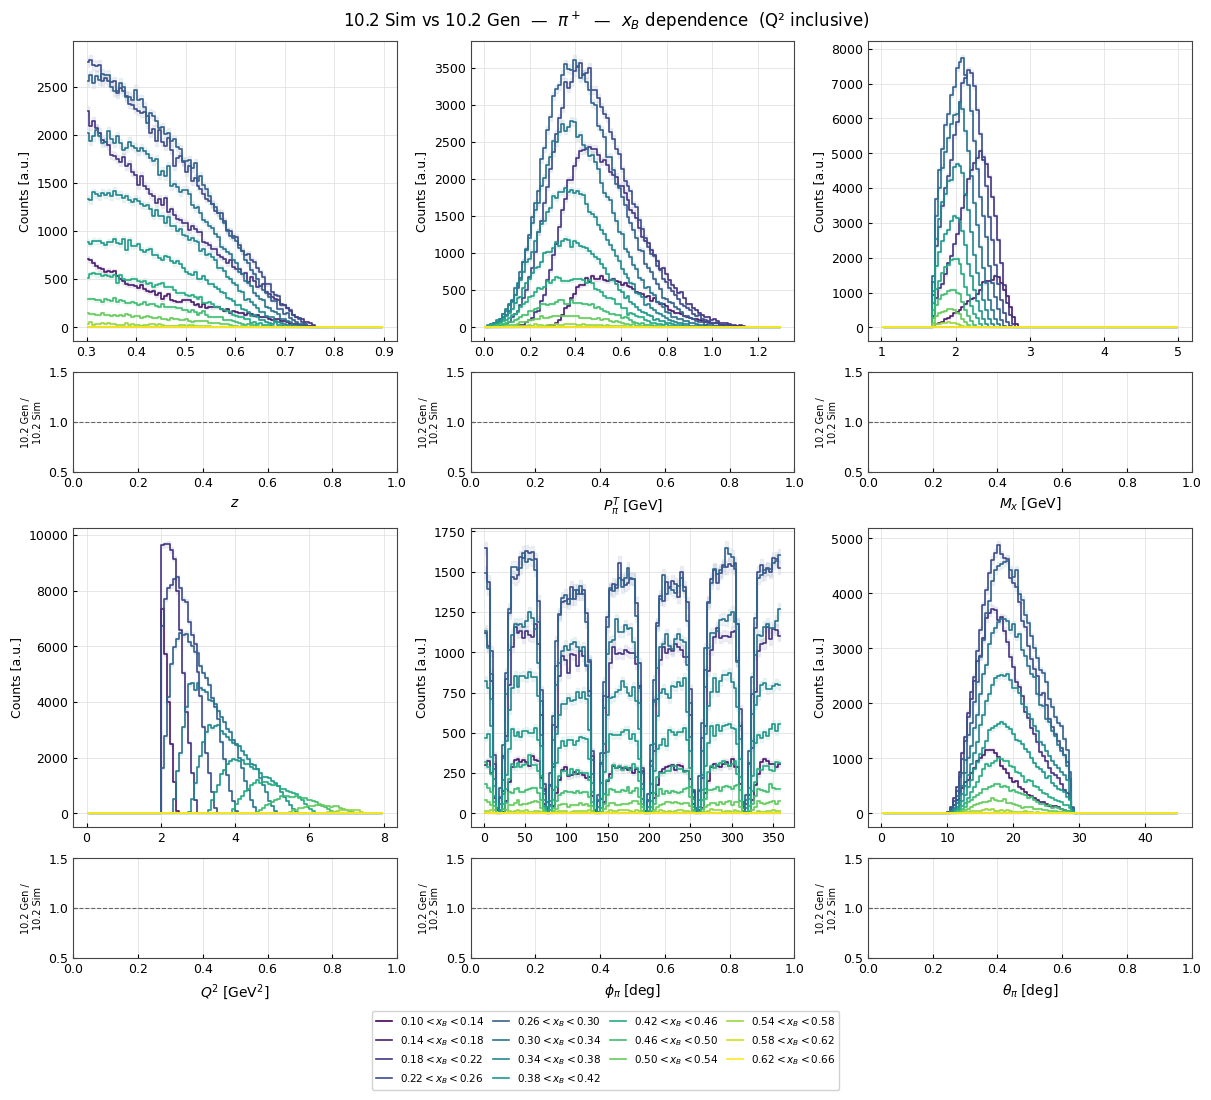

In [384]:
# ── xB dependence: overlay xB bins, fix Q2_BIN=0 (+ data/sim ratio panels) ───
# When exactly 2 files are loaded, a ratio panel (file[1]/file[0]) appears below
# each main panel for every xB bin.

BINS_XB = 14;  XB_MIN, XB_MAX = 0.1, 0.66

def xb_label(k):
    lo = XB_MIN + (k - 1) * (XB_MAX - XB_MIN) / BINS_XB
    hi = XB_MIN +  k      * (XB_MAX - XB_MIN) / BINS_XB
    return rf'${lo:.2f}<x_B<{hi:.2f}$'

_xb_cmap  = mcm.get_cmap('viridis')
XB_COLORS = [_xb_cmap(i / (BINS_XB - 1)) for i in range(BINS_XB)]

XBDEP_VARS = [
    ('hZ',        r'$z$'),
    ('hPt_pi',    r'$P_\pi^T\;[\mathrm{GeV}]$'),
    ('hMx',       r'$M_x\;[\mathrm{GeV}]$'),
    ('hQ2',       r'$Q^2\;[\mathrm{GeV}^2]$'),
    ('hPhi_pi',   r'$\phi_\pi\;[\mathrm{deg}]$'),
    ('hTheta_pi', r'$\theta_\pi\;[\mathrm{deg}]$'),
]

show_xb_ratio = len(datasets) == 2
ncols_x = 3
nrows_x = -(-len(XBDEP_VARS) // ncols_x)
panel_rows_x = nrows_x * 2 if show_xb_ratio else nrows_x

for charge in charge_list:
    fig, axs = plt.subplots(
        panel_rows_x, ncols_x,
        figsize=(ncols_x * 4.0, panel_rows_x * (2.5 if show_xb_ratio else 3.5)),
        constrained_layout=True,
        gridspec_kw={'height_ratios': ([3, 1] * nrows_x if show_xb_ratio else None)}
    )
    title_files = f"{datasets[0]['label']}" + (f" vs {datasets[1]['label']}" if show_xb_ratio else "")
    fig.suptitle(
        rf"{title_files}  —  {CHARGE_LABEL[charge]}  —  $x_B$ dependence  (Q² inclusive)",
        fontsize=12
    )
    axs_flat = np.array(axs).ravel()

    for vi, (hbase, xlabel) in enumerate(XBDEP_VARS):
        row = vi // ncols_x
        col = vi %  ncols_x
        if show_xb_ratio:
            ax_main  = axs_flat[row * 2 * ncols_x + col]
            ax_ratio = axs_flat[row * 2 * ncols_x + col + ncols_x]
        else:
            ax_main  = axs_flat[vi]
            ax_ratio = None

        ref_v = ref_c = None
        for fi, d in enumerate(datasets):
            for k in range(1, BINS_XB + 1):
                result = _load_1d(d['file'], f'{hbase}_{charge}_0_{k}')
                if result is None:
                    continue
                centers, v, e = result
                if NORMALIZE:
                    v, e = _norm(v, e)
                x_color = XB_COLORS[(k - 1) % len(XB_COLORS)]
                ls = LINESTYLES[fi % len(LINESTYLES)]
                ax_main.step(centers, v, color=x_color, lw=1.2, ls=ls,
                             where='mid', label=xb_label(k) if fi == 0 else '_nolegend_')
                ax_main.fill_between(centers, v - e, v + e,
                                     color=x_color, alpha=0.08, step='mid')

                if show_xb_ratio:
                    if fi == 0:
                        if ref_v is None:
                            ref_v = {}; ref_c = {}
                        ref_v[k] = v; ref_c[k] = centers
                    else:
                        if ref_v and k in ref_v and len(v) == len(ref_v[k]):
                            with np.errstate(invalid='ignore', divide='ignore'):
                                rat   = np.where(ref_v[k] > 0, v / ref_v[k], np.nan)
                                rat_e = np.where(ref_v[k] > 0,
                                                 rat * np.sqrt((e / np.where(v > 0, v, 1))**2),
                                                 np.nan)
                            ax_ratio.step(ref_c[k], rat, color=x_color, lw=1.0,
                                          where='mid', label=xb_label(k))
                            ax_ratio.fill_between(ref_c[k],
                                                  np.where(np.isfinite(rat), rat - rat_e, np.nan),
                                                  np.where(np.isfinite(rat), rat + rat_e, np.nan),
                                                  color=x_color, alpha=0.08, step='mid')

        ax_main.set_ylabel('Normalised' if NORMALIZE else 'Counts [a.u.]', fontsize=9)
        if show_xb_ratio:
            ax_ratio.axhline(1, color='#666666', lw=0.8, ls='--')
            ax_ratio.set_ylim(0.5, 1.5)
            ax_ratio.set_ylabel(
                f"{datasets[1]['label']} /\n{datasets[0]['label']}", fontsize=7)
            ax_ratio.set_xlabel(xlabel, fontsize=10)
        else:
            ax_main.set_xlabel(xlabel, fontsize=10)

    for vi in range(len(XBDEP_VARS), nrows_x * ncols_x):
        row = vi // ncols_x; col = vi % ncols_x
        if show_xb_ratio:
            axs_flat[row * 2 * ncols_x + col].set_visible(False)
            axs_flat[row * 2 * ncols_x + col + ncols_x].set_visible(False)
        else:
            axs_flat[vi].set_visible(False)

    handles, labels_leg = axs_flat[0].get_legend_handles_labels()
    fig.legend(handles, labels_leg, loc='upper center',
               bbox_to_anchor=(0.5, 0.0), ncol=4,
               fontsize=7.5, frameon=True, columnspacing=0.8, handlelength=1.5)

    if OUT_DIR:
        fname = f"{OUT_DIR}/xb_dep_{charge}.png"
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        plt.close(fig)
        print(f'Saved {fname}')
    else:
        plt.show()

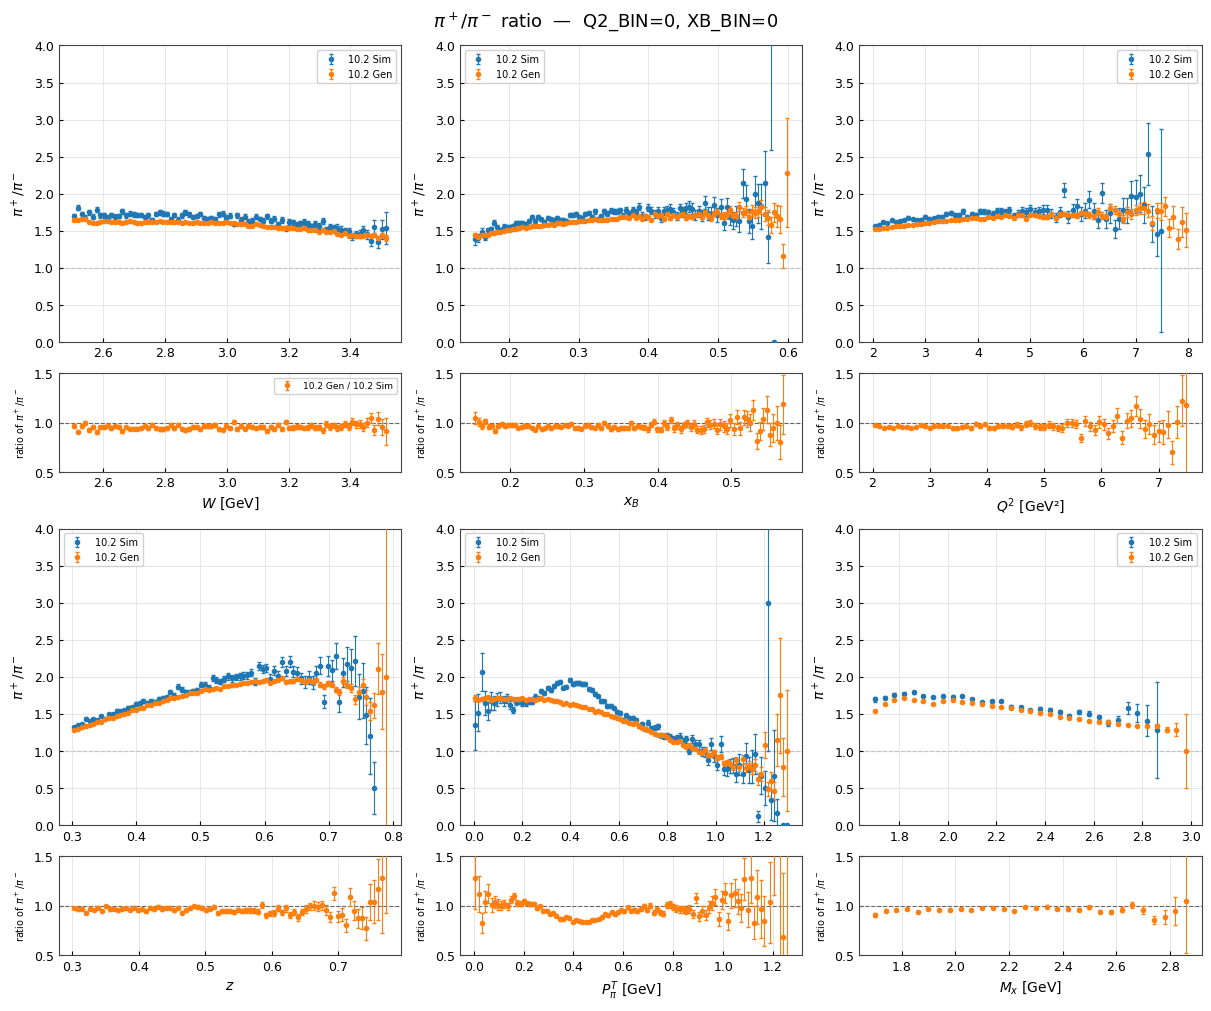

In [385]:
# ── π⁺ / π⁻ ratio vs each 1D variable (+ ratio-of-ratios sub-panels) ─────────
# Main panel : pip/pim for each file, all overlaid.
# Ratio panel: one curve per pair in RATIO_PAIRS showing
#              (pip/pim)[datasets[j]] / (pip/pim)[datasets[i]].

ratio_vars = [
    ('hW',        r'$W$ [GeV]'),
    ('hXb',       r'$x_B$'),
    ('hQ2',       r'$Q^2$ [GeV²]'),
    ('hZ',        r'$z$'),
    ('hPt_pi',    r'$P_\pi^T$ [GeV]'),
    ('hMx',       r'$M_x$ [GeV]'),
]

# Each tuple (i, j) → (pip/pim)[datasets[j]] / (pip/pim)[datasets[i]]
# First pair uses FILES[0] & FILES[1]; second pair uses FILES[2] & FILES[3].
RATIO_PAIRS = [(0, 1), (2, 3)]
valid_pairs = [(i, j) for i, j in RATIO_PAIRS if i < len(datasets) and j < len(datasets)]

show_pi_ratio = len(valid_pairs) > 0
ncols_r      = 3
nrows_r      = -(-len(ratio_vars) // ncols_r)
panel_rows_r = nrows_r * 2 if show_pi_ratio else nrows_r

fig, axs = plt.subplots(
    panel_rows_r, ncols_r,
    figsize=(ncols_r * 4.0, panel_rows_r * (2.5 if show_pi_ratio else 3.5)),
    constrained_layout=True,
    gridspec_kw={'height_ratios': ([3, 1] * nrows_r if show_pi_ratio else None)}
)
fig.suptitle(rf'$\pi^+/\pi^-$ ratio  —  Q2_BIN={Q2_BIN}, XB_BIN={XB_BIN}', fontsize=13)
axs_flat = np.array(axs).ravel()

pair_colors = [FILE_COLORS[j % len(FILE_COLORS)] for _, j in valid_pairs]
pair_labels = [f"{datasets[j]['label']} / {datasets[i]['label']}"
               for i, j in valid_pairs]

for vi, (hbase, xlabel) in enumerate(ratio_vars):
    row = vi // ncols_r
    col = vi %  ncols_r
    if show_pi_ratio:
        ax_main  = axs_flat[row * 2 * ncols_r + col]
        ax_ratio = axs_flat[row * 2 * ncols_r + col + ncols_r]
    else:
        ax_main  = axs_flat[vi]
        ax_ratio = None

    ax_main.axhline(1, color='#888888', lw=0.8, ls='--', zorder=1)

    # Compute and cache pip/pim per file
    cached = {}   # fi → (centers, rat, rat_e)
    for fi, d in enumerate(datasets):
        r_pip = _load_1d(d['file'], f'{hbase}_pip_{BIN_TAG}')
        r_pim = _load_1d(d['file'], f'{hbase}_pim_{BIN_TAG}')
        if r_pip is None or r_pim is None:
            continue
        c_pip, v_pip, e_pip = r_pip
        c_pim, v_pim, e_pim = r_pim
        if len(v_pip) != len(v_pim):
            continue
        with np.errstate(invalid='ignore', divide='ignore'):
            rat   = np.where(v_pim > 0, v_pip / v_pim, np.nan)
            rat_e = np.where(v_pim > 0,
                             rat * np.sqrt((e_pip / np.where(v_pip > 0, v_pip, 1))**2 +
                                           (e_pim / np.where(v_pim > 0, v_pim, 1))**2),
                             np.nan)
        color = FILE_COLORS[fi % len(FILE_COLORS)]
        ax_main.errorbar(c_pip, rat, rat_e,
                         fmt='o', color=color, ms=3, lw=0, elinewidth=0.8,
                         capsize=1.5, label=d['label'], zorder=3)
        cached[fi] = (c_pip, rat, rat_e)

    # Ratio sub-panel: one curve per valid pair
    if show_pi_ratio:
        for pi_idx, (i, j) in enumerate(valid_pairs):
            if i not in cached or j not in cached:
                continue
            c_i, r_i, e_i = cached[i]
            c_j, r_j, e_j = cached[j]
            if len(r_i) != len(r_j):
                continue
            with np.errstate(invalid='ignore', divide='ignore'):
                ds_rat   = np.where(r_i > 0, r_j / r_i, np.nan)
                ds_rat_e = np.where(r_i > 0,
                                    ds_rat * np.sqrt(
                                        (e_j / np.where(r_j > 0, r_j, 1))**2 +
                                        (e_i / np.where(r_i > 0, r_i, 1))**2),
                                    np.nan)
            ax_ratio.errorbar(c_i, ds_rat, ds_rat_e,
                              fmt='o', color=pair_colors[pi_idx], ms=3,
                              lw=0, elinewidth=0.8, capsize=1.5,
                              label=pair_labels[pi_idx], zorder=3)

        ax_ratio.axhline(1, color='#666666', lw=0.8, ls='--')
        ax_ratio.set_ylim(0.5, 1.5)
        ax_ratio.set_ylabel(r'ratio of $\pi^+/\pi^-$', fontsize=7)
        ax_ratio.set_xlabel(xlabel, fontsize=10)
        if vi == 0:
            ax_ratio.legend(fontsize=6.5, loc='best')
    else:
        ax_main.set_xlabel(xlabel, fontsize=10)

    ax_main.set_ylabel(r'$\pi^+/\pi^-$', fontsize=10)
    ax_main.set_ylim(0, 4)
    ax_main.legend(fontsize=7)

for vi in range(len(ratio_vars), nrows_r * ncols_r):
    row = vi // ncols_r; col = vi % ncols_r
    if show_pi_ratio:
        axs_flat[row * 2 * ncols_r + col].set_visible(False)
        axs_flat[row * 2 * ncols_r + col + ncols_r].set_visible(False)
    else:
        axs_flat[vi].set_visible(False)

if OUT_DIR:
    fname = f'{OUT_DIR}/piRatio_{BIN_TAG}.png'
    fig.savefig(fname, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f'Saved {fname}')
else:
    plt.show()
